In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import hashlib

# --------------------------------------------------
# 1. Locate all high-quality .tsd files
# --------------------------------------------------

data_dir = Path("data/high_quality/tctodd")
files = sorted(data_dir.rglob("*.tsd"))

print("DATASET INSPECTION")
print("==================")
print("Dataset path :", data_dir.resolve())
print("Total files  :", len(files))


# --------------------------------------------------
# 2. Inspect every recording
# --------------------------------------------------

records = []
all_arrays = []

duplicate_hashes = {}

for file in files:
    # Extract sign name and instance number
    filename = file.name
    sign_name = filename.rsplit(".", 1)[0].rsplit("-", 1)[0]
    instance = filename.rsplit(".", 1)[0].rsplit("-", 1)[1]

    # Load the raw time-series
    arr = np.genfromtxt(file, delimiter="\t")

    # Basic information
    records.append({
        "file": str(file),
        "sign": sign_name,
        "instance": instance,
        "rows": arr.shape[0] if arr.ndim == 2 else None,
        "columns": arr.shape[1] if arr.ndim == 2 else None,
        "dtype": str(arr.dtype),
        "nan_count": int(np.isnan(arr).sum()) if np.issubdtype(arr.dtype, np.floating) else 0,
        "inf_count": int(np.isinf(arr).sum()) if np.issubdtype(arr.dtype, np.floating) else 0
    })

    # Store numerical values for global statistics
    if arr.ndim == 2:
        all_arrays.append(arr)

        # Hash the complete recording to detect exact duplicates
        arr_bytes = np.ascontiguousarray(arr, dtype=np.float64).tobytes()
        file_hash = hashlib.sha256(arr_bytes).hexdigest()

        duplicate_hashes.setdefault(file_hash, []).append(str(file))


# --------------------------------------------------
# 3. Convert metadata to DataFrame
# --------------------------------------------------

metadata = pd.DataFrame(records)

print("\nMETADATA")
print("========")
print(metadata.head())


# --------------------------------------------------
# 4. Dataset dimensions
# --------------------------------------------------

print("\nDIMENSIONS")
print("==========")
print("Number of recordings :", len(metadata))
print("Unique signs          :", metadata["sign"].nunique())
print("Unique column counts  :", metadata["columns"].unique())
print("Unique row counts     :", metadata["rows"].unique())


# --------------------------------------------------
# 5. Data types
# --------------------------------------------------

print("\nDATA TYPES")
print("==========")
print(metadata["dtype"].value_counts())


# --------------------------------------------------
# 6. Missing / infinite values
# --------------------------------------------------

print("\nMISSING / INVALID VALUES")
print("========================")
print("Total NaN values :", metadata["nan_count"].sum())
print("Total Inf values :", metadata["inf_count"].sum())


# --------------------------------------------------
# 7. Class / target distribution
# --------------------------------------------------

class_distribution = metadata["sign"].value_counts().sort_index()

print("\nCLASS DISTRIBUTION")
print("==================")
print(class_distribution)

print("\nClass count summary:")
print("Minimum samples per class :", class_distribution.min())
print("Maximum samples per class :", class_distribution.max())


# --------------------------------------------------
# 8. Duplicate recordings
# --------------------------------------------------

duplicate_groups = {
    h: paths for h, paths in duplicate_hashes.items()
    if len(paths) > 1
}

print("\nDUPLICATE RECORDINGS")
print("====================")
print("Number of exact duplicate groups :", len(duplicate_groups))

if duplicate_groups:
    for group in list(duplicate_groups.values())[:5]:
        print("\nDuplicate group:")
        for path in group:
            print(path)


# --------------------------------------------------
# 9. Combine all time-series data
# --------------------------------------------------

combined_data = np.concatenate(all_arrays, axis=0)

print("\nCOMBINED TIME-SERIES DATA")
print("=========================")
print("Shape :", combined_data.shape)
print("dtype :", combined_data.dtype)


# --------------------------------------------------
# 10. Basic statistics for all 22 channels
# --------------------------------------------------

feature_names = [
    "left_position_x",
    "left_position_y",
    "left_position_z",
    "left_rotation_1",
    "left_rotation_2",
    "left_rotation_3",
    "left_thumb",
    "left_forefinger",
    "left_middlefinger",
    "left_ringfinger",
    "left_littlefinger",
    "right_position_x",
    "right_position_y",
    "right_position_z",
    "right_rotation_1",
    "right_rotation_2",
    "right_rotation_3",
    "right_thumb",
    "right_forefinger",
    "right_middlefinger",
    "right_ringfinger",
    "right_littlefinger"
]

feature_df = pd.DataFrame(
    combined_data,
    columns=feature_names
)

print("\nBASIC STATISTICS")
print("================")
display(feature_df.describe().T)

DATASET INSPECTION
Dataset path : C:\Users\B R MANASI\OneDrive\ドキュメント\sign-language-project\ASLtoSpeech\data\high_quality\tctodd
Total files  : 2565

METADATA
                                           file   sign instance  rows  \
0  data\high_quality\tctodd\tctodd1\alive-1.tsd  alive        1    50   
1  data\high_quality\tctodd\tctodd1\alive-2.tsd  alive        2    54   
2  data\high_quality\tctodd\tctodd1\alive-3.tsd  alive        3    53   
3    data\high_quality\tctodd\tctodd1\all-1.tsd    all        1    55   
4    data\high_quality\tctodd\tctodd1\all-2.tsd    all        2    60   

   columns    dtype  nan_count  inf_count  
0       22  float64          0          0  
1       22  float64          0          0  
2       22  float64          0          0  
3       22  float64          0          0  
4       22  float64          0          0  

DIMENSIONS
Number of recordings : 2565
Unique signs          : 96
Unique column counts  : [22]
Unique row counts     : [ 50  54  53  55  

,count,mean,std,min,25%,50%,75%,max
left_position_x,146949.0,-0.055462,0.043212,-0.342182,-0.070610,-0.052041,-0.033703,0.284053
left_position_y,146949.0,-0.113013,0.079858,-0.210003,-0.166515,-0.151372,-0.072677,0.451930
left_position_z,146949.0,-0.138106,0.065494,-0.397100,-0.185958,-0.156344,-0.083333,0.279580
left_rotation_1,146949.0,0.598195,0.088800,0.003024,0.569404,0.592280,0.612992,0.997842
left_rotation_2,146949.0,0.307559,0.132904,0.118787,0.223600,0.242668,0.392087,0.993448
left_rotation_3,146949.0,0.463156,0.052315,0.063674,0.450441,0.468691,0.486697,0.674636
left_thumb,146949.0,0.089838,0.229754,0.000000,0.000000,0.000000,0.000000,1.000000
left_forefinger,146949.0,0.052772,0.170532,0.000000,0.000000,0.000000,0.001545,1.000000
left_middlefinger,146949.0,0.030192,0.145386,0.000000,0.000000,0.000000,0.000000,1.000000
left_ringfinger,146949.0,0.055055,0.180508,0.000000,0.000000,0.000000,0.015366,1.000000


In [2]:
# Find classes that do not have the expected 27 recordings

problem_classes = (
    class_distribution[class_distribution != 27]
    .sort_values()
)

print("Classes with counts different from 27:")
print("---------------------------------------")
print(problem_classes)

print("\nNumber of unusual classes:", len(problem_classes))


# Show example files belonging to each unusual class
for sign, count in problem_classes.items():
    print(f"\nSIGN: {sign} | COUNT: {count}")
    
    examples = metadata[
        metadata["sign"] == sign
    ][["file", "sign", "instance"]].head(10)
    
    display(examples)

Classes with counts different from 27:
---------------------------------------
sign
her          3
his_hers    24
Name: count, dtype: int64

Number of unusual classes: 2

SIGN: her | COUNT: 3


,file,sign,instance
90,data\high_quality\tctodd\tctodd1\her-1.tsd,her,1
91,data\high_quality\tctodd\tctodd1\her-2.tsd,her,2
92,data\high_quality\tctodd\tctodd1\her-3.tsd,her,3



SIGN: his_hers | COUNT: 24


,file,sign,instance
375,data\high_quality\tctodd\tctodd2\his_hers-1.tsd,his_hers,1
376,data\high_quality\tctodd\tctodd2\his_hers-2.tsd,his_hers,2
377,data\high_quality\tctodd\tctodd2\his_hers-3.tsd,his_hers,3
660,data\high_quality\tctodd\tctodd3\his_hers-1.tsd,his_hers,1
661,data\high_quality\tctodd\tctodd3\his_hers-2.tsd,his_hers,2
662,data\high_quality\tctodd\tctodd3\his_hers-3.tsd,his_hers,3
945,data\high_quality\tctodd\tctodd4\his_hers-1.tsd,his_hers,1
946,data\high_quality\tctodd\tctodd4\his_hers-2.tsd,his_hers,2
947,data\high_quality\tctodd\tctodd4\his_hers-3.tsd,his_hers,3
1230,data\high_quality\tctodd\tctodd5\his_hers-1.tsd,his_hers,1


In [3]:
# Inspect all recordings belonging to the two unusual labels

for sign in ["her", "his_hers"]:
    print(f"\n===== {sign} =====")
    
    subset = metadata[metadata["sign"] == sign][
        ["file", "sign", "instance", "rows", "columns"]
    ]
    
    display(subset.to_string(index=False))


===== her =====


'                                      file sign instance  rows  columns\ndata\\high_quality\\tctodd\\tctodd1\\her-1.tsd  her        1    52       22\ndata\\high_quality\\tctodd\\tctodd1\\her-2.tsd  her        2    55       22\ndata\\high_quality\\tctodd\\tctodd1\\her-3.tsd  her        3    46       22'


===== his_hers =====


'                                           file     sign instance  rows  columns\ndata\\high_quality\\tctodd\\tctodd2\\his_hers-1.tsd his_hers        1    51       22\ndata\\high_quality\\tctodd\\tctodd2\\his_hers-2.tsd his_hers        2    50       22\ndata\\high_quality\\tctodd\\tctodd2\\his_hers-3.tsd his_hers        3    48       22\ndata\\high_quality\\tctodd\\tctodd3\\his_hers-1.tsd his_hers        1    52       22\ndata\\high_quality\\tctodd\\tctodd3\\his_hers-2.tsd his_hers        2    53       22\ndata\\high_quality\\tctodd\\tctodd3\\his_hers-3.tsd his_hers        3    53       22\ndata\\high_quality\\tctodd\\tctodd4\\his_hers-1.tsd his_hers        1    51       22\ndata\\high_quality\\tctodd\\tctodd4\\his_hers-2.tsd his_hers        2    50       22\ndata\\high_quality\\tctodd\\tctodd4\\his_hers-3.tsd his_hers        3    51       22\ndata\\high_quality\\tctodd\\tctodd5\\his_hers-1.tsd his_hers        1    50       22\ndata\\high_quality\\tctodd\\tctodd5\\his_hers-2.tsd his_h

In [4]:
from pathlib import Path

freq_file = Path("data/high_quality/sign_frequency_data.txt")

print("Checking:", freq_file.resolve())

with open(freq_file, "r") as f:
    lines = f.readlines()

print("\nEntries containing 'her':")
for line in lines:
    if "her" in line.lower():
        print(line.strip())

print("\nTotal entries in sign_frequency_data.txt:", len(lines))

Checking: C:\Users\B R MANASI\OneDrive\ドキュメント\sign-language-project\ASLtoSpeech\data\high_quality\sign_frequency_data.txt

Entries containing 'her':
his_hers 8 24
where 40 27
her 46 3

Total entries in sign_frequency_data.txt: 98


In [5]:
from pathlib import Path

html_file = Path("data/high_quality/ASL-high.html")

with open(html_file, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()

lines = text.splitlines()

print("Lines containing 'her' or 'his_hers':")
print("--------------------------------------")

for i, line in enumerate(lines, start=1):
    if "his_hers" in line.lower() or ">her<" in line.lower() or " her " in line.lower():
        print(f"{i}: {line.strip()}")

Lines containing 'her' or 'his_hers':
--------------------------------------


In [6]:
from pathlib import Path

freq_file = Path("data/high_quality/sign_frequency_data.txt")

with open(freq_file, "r") as f:
    lines = [line.strip() for line in f if line.strip()]

print("FIRST 15 NON-EMPTY LINES")
print("========================")
for i, line in enumerate(lines[:15], start=1):
    print(f"{i}: {line}")

print("\nLAST 15 NON-EMPTY LINES")
print("=======================")
start = max(0, len(lines) - 15)

for i, line in enumerate(lines[start:], start=start + 1):
    print(f"{i}: {line}")

print("\nTotal non-empty lines:", len(lines))

FIRST 15 NON-EMPTY LINES
1: shop 0 27
2: all 1 27
3: forget 2 27
4: money 3 27
5: soon 4 27
6: paper 5 27
7: go 6 27
8: cold 7 27
9: his_hers 8 24
10: thank 9 27
11: flash 10 27
12: innocent 11 27
13: sorry 12 27
14: read 13 27
15: know 14 27

LAST 15 NON-EMPTY LINES
84: draw 83 27
85: I 84 27
86: drink 85 27
87: polite 86 27
88: wrong 87 27
89: why 88 27
90: man 89 27
91: building 90 27
92: maybe 91 27
93: later 92 27
94: hello 93 27
95: hear 94 27
96: spend 95 27
97: 0.088121 -0.196716
98: [Finished in 27.7s]

Total non-empty lines: 98


In [7]:
from pathlib import Path

freq_file = Path("data/high_quality/sign_frequency_data.txt")

with open(freq_file, "r", encoding="utf-8", errors="ignore") as f:
    lines = [line.rstrip("\n") for line in f]

print("Last 12 physical lines in the file")
print("=================================")

for i, line in enumerate(lines[-12:], start=len(lines) - 11):
    print(f"{i}: {repr(line)}")

Last 12 physical lines in the file
87: 'polite 86 27'
88: 'wrong 87 27'
89: 'why 88 27'
90: 'man 89 27'
91: 'building 90 27'
92: 'maybe 91 27'
93: 'later 92 27'
94: 'hello 93 27'
95: 'hear 94 27'
96: 'spend 95 27'
97: '0.088121 -0.196716'
98: '[Finished in 27.7s]'


In [8]:
# Read the repository's class-frequency file
from pathlib import Path

freq_file = Path("data/high_quality/sign_frequency_data.txt")

classes = []

with open(freq_file, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.strip().split()
        
        # Valid class lines have: sign_name class_id count
        if len(parts) == 3 and parts[1].isdigit() and parts[2].isdigit():
            classes.append((int(parts[1]), parts[0], int(parts[2])))

classes = sorted(classes, key=lambda x: x[0])

print("Number of valid class entries:", len(classes))
print("\nClass ID | Sign | Recordings")
print("-" * 35)

for class_id, sign, count in classes:
    print(f"{class_id:8} | {sign:15} | {count}")

Number of valid class entries: 96

Class ID | Sign | Recordings
-----------------------------------
       0 | shop            | 27
       1 | all             | 27
       2 | forget          | 27
       3 | money           | 27
       4 | soon            | 27
       5 | paper           | 27
       6 | go              | 27
       7 | cold            | 27
       8 | his_hers        | 24
       9 | thank           | 27
      10 | flash           | 27
      11 | innocent        | 27
      12 | sorry           | 27
      13 | read            | 27
      14 | know            | 27
      15 | not             | 27
      16 | name            | 27
      17 | glove           | 27
      18 | lose            | 27
      19 | tray            | 27
      20 | right           | 27
      21 | deaf            | 27
      22 | alive           | 27
      23 | zero            | 27
      24 | cost            | 27
      25 | girl            | 27
      26 | Norway          | 27
      27 | yes             | 27
    

In [9]:
# Check where the "her" and "his_hers" recordings are located

subset = metadata[
    metadata["sign"].isin(["her", "his_hers"])
].copy()

subset["session"] = (
    subset["file"]
    .str.extract(r"(tctodd\d+)")
)

session_counts = (
    subset.groupby(["session", "sign"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print("Recordings per session:")
print("=======================")
print(session_counts)

print("\nDetailed files:")
print("================")

display(
    subset[
        ["file", "sign", "instance", "rows", "columns"]
    ].sort_values(["session", "sign", "instance"])
)

Recordings per session:
sign     her  his_hers
session               
tctodd1    3         0
tctodd2    0         3
tctodd3    0         3
tctodd4    0         3
tctodd5    0         3
tctodd6    0         3
tctodd7    0         3
tctodd8    0         3
tctodd9    0         3

Detailed files:


KeyError: 'session'

In [ ]:
from pathlib import Path
from collections import Counter

data_dir = Path("data/high_quality/tctodd")

session_counts = {}

for session_dir in sorted(data_dir.iterdir()):
    if session_dir.is_dir():
        count = len(list(session_dir.rglob("*.tsd")))
        session_counts[session_dir.name] = count

print("Recordings in each session")
print("==========================")

for session, count in session_counts.items():
    print(f"{session}: {count}")

print("\nTotal:", sum(session_counts.values()))

Recordings in each session
tctodd1: 285
tctodd2: 285
tctodd3: 285
tctodd4: 285
tctodd5: 285
tctodd6: 285
tctodd7: 285
tctodd8: 285
tctodd9: 285

Total: 2565


In [ ]:
# Compare the sign labels present in each recording session

session_labels = {}

for session in sorted(metadata["file"].str.extract(r"(tctodd\d+)")[0].dropna().unique()):
    session_labels[session] = set(
        metadata.loc[
            metadata["file"].str.contains(session, regex=False),
            "sign"
        ]
    )

print("Unique labels in each session")
print("============================")

for session, labels in session_labels.items():
    print(f"{session}: {len(labels)} unique labels")

print("\nDifferences involving 'her' and 'his_hers'")
print("============================================")

for session in ["tctodd1", "tctodd2"]:
    print(f"\n{session}:")
    print("Contains her      :", "her" in session_labels[session])
    print("Contains his_hers :", "his_hers" in session_labels[session])

# Compare tctodd1 with tctodd2
only_in_tctodd1 = session_labels["tctodd1"] - session_labels["tctodd2"]
only_in_tctodd2 = session_labels["tctodd2"] - session_labels["tctodd1"]

print("\nLabels only in tctodd1:")
print(sorted(only_in_tctodd1))

print("\nLabels only in tctodd2:")
print(sorted(only_in_tctodd2))

Unique labels in each session
tctodd1: 95 unique labels
tctodd2: 95 unique labels
tctodd3: 95 unique labels
tctodd4: 95 unique labels
tctodd5: 95 unique labels
tctodd6: 95 unique labels
tctodd7: 95 unique labels
tctodd8: 95 unique labels
tctodd9: 95 unique labels

Differences involving 'her' and 'his_hers'

tctodd1:
Contains her      : True
Contains his_hers : False

tctodd2:
Contains her      : False
Contains his_hers : True

Labels only in tctodd1:
['her']

Labels only in tctodd2:
['his_hers']


In [ ]:
# Create a copy so the raw metadata remains untouched
metadata_clean = metadata.copy()

# Count before correction
print("Before correction:")
print("her:", (metadata_clean["sign"] == "her").sum())
print("his_hers:", (metadata_clean["sign"] == "his_hers").sum())

# Apply the justified label correction
metadata_clean.loc[
    metadata_clean["sign"] == "her",
    "sign"
] = "his_hers"

# Verify after correction
print("\nAfter correction:")
print("her:", (metadata_clean["sign"] == "her").sum())
print("his_hers:", (metadata_clean["sign"] == "his_hers").sum())

print("\nTotal classes:", metadata_clean["sign"].nunique())

print("\nClass-count range:")
print("Minimum:", metadata_clean["sign"].value_counts().min())
print("Maximum:", metadata_clean["sign"].value_counts().max())

Before correction:
her: 3
his_hers: 24

After correction:
her: 0
his_hers: 27

Total classes: 95

Class-count range:
Minimum: 27
Maximum: 27


In [ ]:
print("Recording length statistics")
print("===========================")

print(metadata_clean["rows"].describe())

print("\nShortest recordings:")
display(
    metadata_clean.nsmallest(10, "rows")[
        ["file", "sign", "rows"]
    ]
)

print("\nLongest recordings:")
display(
    metadata_clean.nlargest(10, "rows")[
        ["file", "sign", "rows"]
    ]
)

Recording length statistics
count    2565.000000
mean       57.290058
std         7.461712
min        45.000000
25%        53.000000
50%        55.000000
75%        60.000000
max       136.000000
Name: rows, dtype: float64

Shortest recordings:


,file,sign,rows
428,data\high_quality\tctodd\tctodd2\mine-3.tsd,mine,45
92,data\high_quality\tctodd\tctodd1\her-3.tsd,his_hers,46
143,data\high_quality\tctodd\tctodd1\mine-3.tsd,mine,46
709,data\high_quality\tctodd\tctodd3\maybe-2.tsd,maybe,46
962,data\high_quality\tctodd\tctodd4\I-3.tsd,I,46
89,data\high_quality\tctodd\tctodd1\hello-3.tsd,hello,47
107,data\high_quality\tctodd\tctodd1\I-3.tsd,I,47
142,data\high_quality\tctodd\tctodd1\mine-2.tsd,mine,47
223,data\high_quality\tctodd\tctodd1\take-2.tsd,take,47
224,data\high_quality\tctodd\tctodd1\take-3.tsd,take,47



Longest recordings:


,file,sign,rows
1811,data\high_quality\tctodd\tctodd7\hurry-3.tsd,hurry,136
1942,data\high_quality\tctodd\tctodd7\think-2.tsd,think,101
177,data\high_quality\tctodd\tctodd1\read-1.tsd,read,96
2008,data\high_quality\tctodd\tctodd8\building-2.tsd,building,95
1646,data\high_quality\tctodd\tctodd6\surprise-3.tsd,surprise,93
252,data\high_quality\tctodd\tctodd1\where-1.tsd,where,92
1472,data\high_quality\tctodd\tctodd6\draw-3.tsd,draw,92
1592,data\high_quality\tctodd\tctodd6\pen-3.tsd,pen,92
243,data\high_quality\tctodd\tctodd1\wait_notyet_-...,wait_notyet_,91
75,data\high_quality\tctodd\tctodd1\God-1.tsd,God,90


In [ ]:
import matplotlib.pyplot as plt

length_counts = metadata_clean["rows"].value_counts().sort_index()

print("Most common recording lengths:")
print("=============================")
print(length_counts.head(20))

print("\nLength frequency summary:")
print("=========================")

print("Recordings with <= 50 time steps:",
      (metadata_clean["rows"] <= 50).sum())

print("Recordings with 51-65 time steps:",
      ((metadata_clean["rows"] >= 51) &
       (metadata_clean["rows"] <= 65)).sum())

print("Recordings with 66-80 time steps:",
      ((metadata_clean["rows"] >= 66) &
       (metadata_clean["rows"] <= 80)).sum())

print("Recordings with > 80 time steps:",
      (metadata_clean["rows"] > 80).sum())


# Plot the distribution
plt.figure(figsize=(10, 5))
plt.hist(
    metadata_clean["rows"],
    bins=range(
        metadata_clean["rows"].min(),
        metadata_clean["rows"].max() + 2
    ),
    edgecolor="black"
)

plt.axvline(
    metadata_clean["rows"].mean(),
    linestyle="--",
    label=f"Mean = {metadata_clean['rows'].mean():.2f}"
)

plt.axvline(
    57,
    linestyle=":",
    label="Reference length = 57"
)

plt.xlabel("Number of time steps")
plt.ylabel("Number of recordings")
plt.title("Distribution of Auslan High-Quality Recording Lengths")
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
python -m pip install matplotlib

SyntaxError: invalid syntax (2739118891.py, line 1)

In [ ]:
import matplotlib.pyplot as plt
print("Matplotlib works in notebook")

Matplotlib works in notebook


Most common recording lengths:
rows
45      1
46      4
47     15
48     41
49     71
50    109
51    172
52    194
53    212
54    230
55    236
56    203
57    179
58    151
59    102
60    104
61     83
62     70
63     46
64     38
Name: count, dtype: int64

Length frequency summary:
Recordings with <= 50 time steps: 241
Recordings with 51-65 time steps: 2061
Recordings with 66-80 time steps: 211
Recordings with > 80 time steps: 52


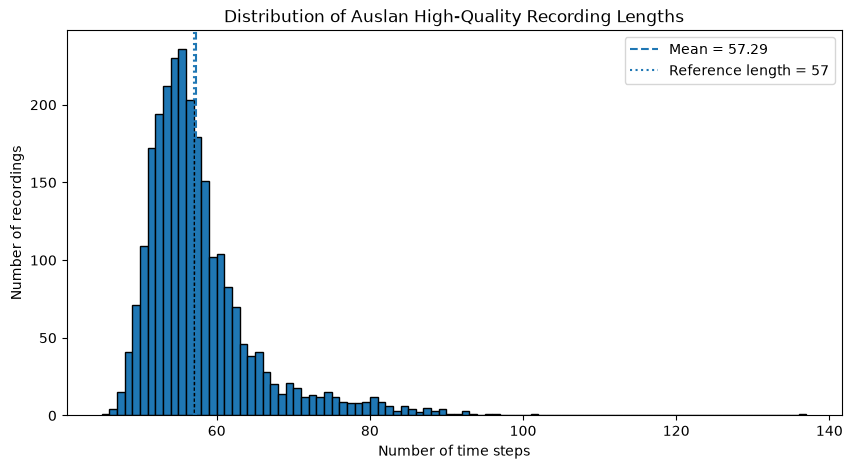

In [ ]:
import matplotlib.pyplot as plt

length_counts = metadata_clean["rows"].value_counts().sort_index()

print("Most common recording lengths:")
print("=============================")
print(length_counts.head(20))

print("\nLength frequency summary:")
print("=========================")

print(
    "Recordings with <= 50 time steps:",
    (metadata_clean["rows"] <= 50).sum()
)

print(
    "Recordings with 51-65 time steps:",
    (
        (metadata_clean["rows"] >= 51) &
        (metadata_clean["rows"] <= 65)
    ).sum()
)

print(
    "Recordings with 66-80 time steps:",
    (
        (metadata_clean["rows"] >= 66) &
        (metadata_clean["rows"] <= 80)
    ).sum()
)

print(
    "Recordings with > 80 time steps:",
    (metadata_clean["rows"] > 80).sum()
)

# Plot the distribution
plt.figure(figsize=(10, 5))

plt.hist(
    metadata_clean["rows"],
    bins=range(
        metadata_clean["rows"].min(),
        metadata_clean["rows"].max() + 2
    ),
    edgecolor="black"
)

plt.axvline(
    metadata_clean["rows"].mean(),
    linestyle="--",
    label=f"Mean = {metadata_clean['rows'].mean():.2f}"
)

plt.axvline(
    57,
    linestyle=":",
    label="Reference length = 57"
)

plt.xlabel("Number of time steps")
plt.ylabel("Number of recordings")
plt.title("Distribution of Auslan High-Quality Recording Lengths")
plt.legend()
plt.show()

In [ ]:
# Investigate recordings longer than 80 time steps

long_recordings = metadata_clean[
    metadata_clean["rows"] > 80
].copy()

print("Number of recordings > 80 time steps:", len(long_recordings))

print("\nLong recording length statistics:")
print(long_recordings["rows"].describe())

print("\nLong recordings by sign:")
print(
    long_recordings["sign"]
    .value_counts()
    .sort_index()
)

print("\nAll recordings > 80 time steps:")
display(
    long_recordings[
        ["file", "sign", "instance", "rows", "columns"]
    ].sort_values("rows", ascending=False)
)

Number of recordings > 80 time steps: 52

Long recording length statistics:
count     52.000000
mean      86.903846
std        8.272941
min       81.000000
25%       82.000000
50%       85.000000
75%       89.000000
max      136.000000
Name: rows, dtype: float64

Long recordings by sign:
sign
God               2
all               1
boy               1
building          3
change_mind_      1
come              1
computer_PC_      1
cost              1
danger            1
draw              4
flash-light       1
girl              2
glove             1
hurry             1
hurt              1
innocent          2
later             3
love              2
make              1
maybe             1
not-my-problem    1
pen               1
question          1
read              2
sad               1
science           2
surprise          1
take              1
think             1
us                1
wait_notyet_      1
when              1
where             1
wild              2
write             3
yes   

,file,sign,instance,rows,columns
1811,data\high_quality\tctodd\tctodd7\hurry-3.tsd,hurry,3,136,22
1942,data\high_quality\tctodd\tctodd7\think-2.tsd,think,2,101,22
177,data\high_quality\tctodd\tctodd1\read-1.tsd,read,1,96,22
2008,data\high_quality\tctodd\tctodd8\building-2.tsd,building,2,95,22
1646,data\high_quality\tctodd\tctodd6\surprise-3.tsd,surprise,3,93,22
252,data\high_quality\tctodd\tctodd1\where-1.tsd,where,1,92,22
1472,data\high_quality\tctodd\tctodd6\draw-3.tsd,draw,3,92,22
1592,data\high_quality\tctodd\tctodd6\pen-3.tsd,pen,3,92,22
243,data\high_quality\tctodd\tctodd1\wait_notyet_-...,wait_notyet_,1,91,22
75,data\high_quality\tctodd\tctodd1\God-1.tsd,God,1,90,22


In [ ]:
# Investigate the three "hurry" recordings

hurry = metadata_clean[
    metadata_clean["sign"] == "hurry"
].copy()

print("HURRY RECORDINGS")
print("================")

display(
    hurry[
        ["file", "sign", "instance", "rows", "columns"]
    ].sort_values("instance")
)


# Load the three recordings and inspect their numerical ranges

print("\nNUMERICAL RANGE OF EACH RECORDING")
print("=================================")

for _, row in hurry.sort_values("instance").iterrows():
    arr = np.genfromtxt(row["file"], delimiter="\t")

    print(
        f"\n{row['instance']}: {row['rows']} time steps"
    )
    print("Minimum value:", arr.min())
    print("Maximum value:", arr.max())
    print("NaN values   :", np.isnan(arr).sum())
    print("Inf values   :", np.isinf(arr).sum())

HURRY RECORDINGS


,file,sign,instance,rows,columns
99,data\high_quality\tctodd\tctodd1\hurry-1.tsd,hurry,1,67,22
2379,data\high_quality\tctodd\tctodd9\hurry-1.tsd,hurry,1,74,22
384,data\high_quality\tctodd\tctodd2\hurry-1.tsd,hurry,1,54,22
2094,data\high_quality\tctodd\tctodd8\hurry-1.tsd,hurry,1,66,22
669,data\high_quality\tctodd\tctodd3\hurry-1.tsd,hurry,1,54,22
1809,data\high_quality\tctodd\tctodd7\hurry-1.tsd,hurry,1,54,22
954,data\high_quality\tctodd\tctodd4\hurry-1.tsd,hurry,1,48,22
1524,data\high_quality\tctodd\tctodd6\hurry-1.tsd,hurry,1,55,22
1239,data\high_quality\tctodd\tctodd5\hurry-1.tsd,hurry,1,54,22
2095,data\high_quality\tctodd\tctodd8\hurry-2.tsd,hurry,2,67,22



NUMERICAL RANGE OF EACH RECORDING

1: 67 time steps
Minimum value: -0.176311
Maximum value: 1.0
NaN values   : 0
Inf values   : 0

1: 74 time steps
Minimum value: -0.202568
Maximum value: 1.0
NaN values   : 0
Inf values   : 0

1: 54 time steps
Minimum value: -0.150889
Maximum value: 1.0
NaN values   : 0
Inf values   : 0

1: 66 time steps
Minimum value: -0.175457
Maximum value: 1.0
NaN values   : 0
Inf values   : 0

1: 54 time steps
Minimum value: -0.170929
Maximum value: 1.0
NaN values   : 0
Inf values   : 0

1: 54 time steps
Minimum value: -0.233235
Maximum value: 1.0
NaN values   : 0
Inf values   : 0

1: 48 time steps
Minimum value: -0.259303
Maximum value: 1.0
NaN values   : 0
Inf values   : 0

1: 55 time steps
Minimum value: -0.229937
Maximum value: 1.0
NaN values   : 0
Inf values   : 0

1: 54 time steps
Minimum value: -0.293175
Maximum value: 1.0
NaN values   : 0
Inf values   : 0

2: 67 time steps
Minimum value: -0.188226
Maximum value: 1.0
NaN values   : 0
Inf values   : 0

2: 5

In [ ]:
import scipy.signal

# Store resampled recordings here
resampled_data = []
resampled_labels = []

TARGET_LENGTH = 57

for _, row in metadata_clean.iterrows():
    # Load the original raw recording
    series = np.genfromtxt(row["file"], delimiter="\t")

    # Resample from its original length to 57 time steps
    resampled_series = scipy.signal.resample(
        series,
        TARGET_LENGTH,
        axis=0
    )

    resampled_data.append(resampled_series)
    resampled_labels.append(row["sign"])

# Convert to NumPy arrays
X_resampled = np.stack(resampled_data)
y_resampled = np.array(resampled_labels)

print("Temporal normalization completed.")
print("X_resampled shape:", X_resampled.shape)
print("y_resampled shape:", y_resampled.shape)

print("\nOriginal number of recordings:",
      len(metadata_clean))

print("Resampled number of recordings:",
      X_resampled.shape[0])

print("Target time steps:",
      X_resampled.shape[1])

print("Number of features:",
      X_resampled.shape[2])

Temporal normalization completed.
X_resampled shape: (2565, 57, 22)
y_resampled shape: (2565,)

Original number of recordings: 2565
Resampled number of recordings: 2565
Target time steps: 57
Number of features: 22


In [ ]:
print("TEMPORAL NORMALIZATION VERIFICATION")
print("====================================")

print("Shape:", X_resampled.shape)
print("NaN values:", np.isnan(X_resampled).sum())
print("Inf values:", np.isinf(X_resampled).sum())

print("\nValue range:")
print("Minimum:", X_resampled.min())
print("Maximum:", X_resampled.max())

print("\nClass count:")
resampled_class_counts = pd.Series(y_resampled).value_counts().sort_index()

print("Number of classes:", resampled_class_counts.size)
print("Minimum samples per class:", resampled_class_counts.min())
print("Maximum samples per class:", resampled_class_counts.max())

TEMPORAL NORMALIZATION VERIFICATION
Shape: (2565, 57, 22)
NaN values: 0
Inf values: 0

Value range:
Minimum: -0.46201825002490504
Maximum: 1.165046859461354

Class count:
Number of classes: 95
Minimum samples per class: 27
Maximum samples per class: 27


In [ ]:
# Test the spatial scaling operation on one recording only

sample = X_resampled[0].copy()

print("BEFORE SPATIAL SCALING")
print("======================")
print("Shape:", sample.shape)
print("Overall minimum:", sample.min())
print("Overall maximum:", sample.max())

# Apply the same logic used by the repository
mins = np.min(sample, axis=0)
shifted = sample - mins

maxs = np.max(shifted, axis=0) + 1e-15
scaled_sample = shifted / maxs

print("\nAFTER SPATIAL SCALING")
print("=====================")
print("Shape:", scaled_sample.shape)
print("Overall minimum:", scaled_sample.min())
print("Overall maximum:", scaled_sample.max())

print("\nPer-feature minimum range:")
print("Minimum of feature minima:", scaled_sample.min(axis=0).min())
print("Maximum of feature minima:", scaled_sample.min(axis=0).max())

print("\nPer-feature maximum range:")
print("Minimum of feature maxima:", scaled_sample.max(axis=0).min())
print("Maximum of feature maxima:", scaled_sample.max(axis=0).max())

BEFORE SPATIAL SCALING
Shape: (57, 22)
Overall minimum: -0.1404677185880206
Overall maximum: 0.7709751001282862

AFTER SPATIAL SCALING
Shape: (57, 22)
Overall minimum: 0.0
Overall maximum: 0.9999999999999972

Per-feature minimum range:
Minimum of feature minima: 0.0
Maximum of feature minima: 0.0

Per-feature maximum range:
Minimum of feature maxima: 0.0
Maximum of feature maxima: 0.9999999999999972


In [ ]:
# Check how often each of the 22 features is constant
# within an individual recording.

# Range of each feature within each recording
feature_ranges = X_resampled.max(axis=1) - X_resampled.min(axis=1)

# A feature is considered constant when its range is exactly zero
constant_mask = feature_ranges == 0

# Count constant occurrences for each feature across all recordings
constant_counts = constant_mask.sum(axis=0)

feature_names = [
    "left_position_x",
    "left_position_y",
    "left_position_z",
    "left_rotation_1",
    "left_rotation_2",
    "left_rotation_3",
    "left_thumb",
    "left_forefinger",
    "left_middlefinger",
    "left_ringfinger",
    "left_littlefinger",
    "right_position_x",
    "right_position_y",
    "right_position_z",
    "right_rotation_1",
    "right_rotation_2",
    "right_rotation_3",
    "right_thumb",
    "right_forefinger",
    "right_middlefinger",
    "right_ringfinger",
    "right_littlefinger"
]

constant_summary = pd.DataFrame({
    "feature": feature_names,
    "constant_recordings": constant_counts,
    "percentage_of_recordings": (
        constant_counts / X_resampled.shape[0] * 100
    )
})

print("CONSTANT-FEATURE ANALYSIS")
print("=========================")

display(
    constant_summary.sort_values(
        "constant_recordings",
        ascending=False
    )
)

print(
    "\nTotal constant feature-recording pairs:",
    constant_mask.sum()
)

print(
    "Total possible feature-recording pairs:",
    constant_mask.size
)

print(
    "Percentage constant:",
    constant_mask.mean() * 100
)

CONSTANT-FEATURE ANALYSIS


,feature,constant_recordings,percentage_of_recordings
8,left_middlefinger,2060,80.311891
18,right_forefinger,1555,60.623782
6,left_thumb,1528,59.571150
7,left_forefinger,1304,50.838207
9,left_ringfinger,1072,41.793372
20,right_ringfinger,805,31.384016
10,left_littlefinger,367,14.307992
17,right_thumb,190,7.407407
21,right_littlefinger,142,5.536062
19,right_middlefinger,26,1.013645



Total constant feature-recording pairs: 9049
Total possible feature-recording pairs: 56430
Percentage constant: 16.03579656211235


In [ ]:
# Inspect the actual values of frequently constant finger-bend features

constant_features_to_check = [
    "left_middlefinger",
    "right_forefinger",
    "left_thumb",
    "left_forefinger",
    "left_ringfinger",
    "right_ringfinger"
]

print("CONSTANT VALUE INSPECTION")
print("========================")

for feature_name in constant_features_to_check:
    
    feature_idx = feature_names.index(feature_name)
    
    # Get values where this feature is constant within a recording
    values = []
    
    for sample_idx in range(X_resampled.shape[0]):
        sample_feature = X_resampled[sample_idx, :, feature_idx]
        
        if np.ptp(sample_feature) == 0:
            values.append(sample_feature[0])
    
    values = np.array(values)
    
    unique_values, counts = np.unique(
        values,
        return_counts=True
    )
    
    print(f"\n{feature_name}")
    print(f"Constant recordings: {len(values)}")
    print(f"Minimum constant value: {values.min()}")
    print(f"Maximum constant value: {values.max()}")
    print("Most common constant values:")
    
    top_indices = np.argsort(counts)[::-1][:10]
    
    for idx in top_indices:
        print(
            f"  {unique_values[idx]:.6f}"
            f" -> {counts[idx]} recordings"
        )

CONSTANT VALUE INSPECTION

left_middlefinger
Constant recordings: 2060
Minimum constant value: 0.0
Maximum constant value: 0.0
Most common constant values:
  0.000000 -> 2060 recordings

right_forefinger
Constant recordings: 1555
Minimum constant value: 0.0
Maximum constant value: 0.0
Most common constant values:
  0.000000 -> 1555 recordings

left_thumb
Constant recordings: 1528
Minimum constant value: 0.0
Maximum constant value: 0.0
Most common constant values:
  0.000000 -> 1528 recordings

left_forefinger
Constant recordings: 1304
Minimum constant value: 0.0
Maximum constant value: 0.0
Most common constant values:
  0.000000 -> 1304 recordings

left_ringfinger
Constant recordings: 1072
Minimum constant value: 0.0
Maximum constant value: 0.0
Most common constant values:
  0.000000 -> 1072 recordings

right_ringfinger
Constant recordings: 805
Minimum constant value: 0.0
Maximum constant value: 0.0
Most common constant values:
  0.000000 -> 805 recordings


In [ ]:
# Spatial normalization
# Each feature within each recording is scaled independently to [0, 1]

mins = np.min(X_resampled, axis=1, keepdims=True)
maxs = np.max(X_resampled, axis=1, keepdims=True)

range_values = maxs - mins

# Avoid division by zero for channels that are constant
range_values[range_values == 0] = 1.0

X_spatial = (X_resampled - mins) / range_values

print("SPATIAL NORMALIZATION COMPLETED")
print("================================")

print("Shape:", X_spatial.shape)
print("NaN values:", np.isnan(X_spatial).sum())
print("Inf values:", np.isinf(X_spatial).sum())

print("\nOverall minimum:", X_spatial.min())
print("Overall maximum:", X_spatial.max())

SPATIAL NORMALIZATION COMPLETED
Shape: (2565, 57, 22)
NaN values: 0
Inf values: 0

Overall minimum: 0.0
Overall maximum: 1.0


In [ ]:
# Verify spatial normalization

sample_mins = X_spatial.min(axis=1)
sample_maxs = X_spatial.max(axis=1)

original_ranges = X_resampled.max(axis=1) - X_resampled.min(axis=1)
varying_features = original_ranges > 0

normalized_mins = sample_mins[varying_features]
normalized_maxs = sample_maxs[varying_features]

print("SPATIAL NORMALIZATION VERIFICATION")
print("==================================")

print(
    "Number of varying feature-recording pairs:",
    varying_features.sum()
)

print(
    "Number of constant feature-recording pairs:",
    (~varying_features).sum()
)

print(
    "\nMaximum deviation of normalized minimum from 0:",
    np.abs(normalized_mins).max()
)

print(
    "Maximum deviation of normalized maximum from 1:",
    np.abs(normalized_maxs - 1).max()
)

# Check values in constant feature-recording pairs
constant_values = []

for sample_idx in range(X_spatial.shape[0]):
    for feature_idx in range(X_spatial.shape[2]):
        if not varying_features[sample_idx, feature_idx]:
            constant_values.append(
                X_spatial[sample_idx, :, feature_idx]
            )

constant_values = np.concatenate(constant_values)

print(
    "\nUnique values in constant feature-recording pairs:",
    np.unique(constant_values)
)

SPATIAL NORMALIZATION VERIFICATION
Number of varying feature-recording pairs: 47381
Number of constant feature-recording pairs: 9049

Maximum deviation of normalized minimum from 0: 0.0
Maximum deviation of normalized maximum from 1: 0.0

Unique values in constant feature-recording pairs: [0.]


In [ ]:
# Verify that every sign has 3 recordings in every session

metadata_clean["session"] = metadata_clean["file"].str.extract(
    r"(tctodd\d+)"
)[0]

session_class_counts = (
    metadata_clean
    .groupby(["sign", "session"])
    .size()
)

print("SESSION / CLASS STRUCTURE")
print("=========================")

print(
    "Unique recordings per sign-session combination:",
    sorted(session_class_counts.unique())
)

print(
    "Number of sign-session combinations:",
    len(session_class_counts)
)

print(
    "Expected combinations:",
    95 * 9
)

print(
    "\nAll combinations have exactly 3 recordings:",
    (session_class_counts == 3).all()
)

print("\nRecordings per session:")
print(
    metadata_clean.groupby("session").size()
)

print("\nRecommended split:")
print("Training sessions: tctodd1 to tctodd6")
print("Testing sessions : tctodd7 to tctodd9")
print("Training recordings:", 95 * 6 * 3)
print("Testing recordings :", 95 * 3 * 3)

SESSION / CLASS STRUCTURE
Unique recordings per sign-session combination: [np.int64(3)]
Number of sign-session combinations: 855
Expected combinations: 855

All combinations have exactly 3 recordings: True

Recordings per session:
session
tctodd1    285
tctodd2    285
tctodd3    285
tctodd4    285
tctodd5    285
tctodd6    285
tctodd7    285
tctodd8    285
tctodd9    285
dtype: int64

Recommended split:
Training sessions: tctodd1 to tctodd6
Testing sessions : tctodd7 to tctodd9
Training recordings: 1710
Testing recordings : 855


In [ ]:
# Create a session-based train/test split

train_sessions = [
    "tctodd1", "tctodd2", "tctodd3",
    "tctodd4", "tctodd5", "tctodd6"
]

test_sessions = [
    "tctodd7", "tctodd8", "tctodd9"
]

# Use the session information already stored in metadata_clean
train_mask = metadata_clean["session"].isin(train_sessions)
test_mask = metadata_clean["session"].isin(test_sessions)

# Split the preprocessed sequence data
X_train = X_spatial[train_mask.to_numpy()]
X_test = X_spatial[test_mask.to_numpy()]

y_train = y_resampled[train_mask.to_numpy()]
y_test = y_resampled[test_mask.to_numpy()]

print("TRAIN / TEST SPLIT")
print("==================")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

print("\nTotal samples:", len(X_train) + len(X_test))


# Check class distribution
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

print("\nTraining class count range:")
print("Minimum:", train_counts.min())
print("Maximum:", train_counts.max())

print("\nTesting class count range:")
print("Minimum:", test_counts.min())
print("Maximum:", test_counts.max())

print("\nAll training classes have 18 recordings:",
      (train_counts == 18).all())

print("All testing classes have 9 recordings:",
      (test_counts == 9).all())

TRAIN / TEST SPLIT
X_train shape: (1710, 57, 22)
y_train shape: (1710,)
X_test shape : (855, 57, 22)
y_test shape : (855,)

Total samples: 2565

Training class count range:
Minimum: 18
Maximum: 18

Testing class count range:
Minimum: 9
Maximum: 9

All training classes have 18 recordings: True
All testing classes have 9 recordings: True


In [ ]:
# Verify that train and test sessions are completely separated

train_sessions_actual = set(
    metadata_clean.loc[train_mask, "session"]
)

test_sessions_actual = set(
    metadata_clean.loc[test_mask, "session"]
)

print("TRAIN SESSIONS")
print("==============")
print(sorted(train_sessions_actual))

print("\nTEST SESSIONS")
print("=============")
print(sorted(test_sessions_actual))

print("\nSESSION OVERLAP")
print("===============")
print("Overlapping sessions:",
      train_sessions_actual & test_sessions_actual)

print("\nNo session leakage:",
      len(train_sessions_actual & test_sessions_actual) == 0)


# Verify every class occurs in both sets
train_labels = set(y_train)
test_labels = set(y_test)

print("\nCLASS COVERAGE")
print("==============")
print("Training classes:", len(train_labels))
print("Testing classes :", len(test_labels))

print("Classes missing from training:",
      sorted(test_labels - train_labels))

print("Classes missing from testing:",
      sorted(train_labels - test_labels))

print(
    "All 95 classes present in both:",
    len(train_labels) == 95 and len(test_labels) == 95
)

TRAIN SESSIONS
['tctodd1', 'tctodd2', 'tctodd3', 'tctodd4', 'tctodd5', 'tctodd6']

TEST SESSIONS
['tctodd7', 'tctodd8', 'tctodd9']

SESSION OVERLAP
Overlapping sessions: set()

No session leakage: True

CLASS COVERAGE
Training classes: 95
Testing classes : 95
Classes missing from training: []
Classes missing from testing: []
All 95 classes present in both: True


In [ ]:
print("FINAL TRAIN / TEST VALUE VERIFICATION")
print("======================================")

print("TRAIN")
print("-----")
print("Shape:", X_train.shape)
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())
print("NaN:", np.isnan(X_train).sum())
print("Inf:", np.isinf(X_train).sum())

print("\nTEST")
print("----")
print("Shape:", X_test.shape)
print("Minimum:", X_test.min())
print("Maximum:", X_test.max())
print("NaN:", np.isnan(X_test).sum())
print("Inf:", np.isinf(X_test).sum())

print("\nLABELS")
print("------")
print("Training classes:", len(np.unique(y_train)))
print("Testing classes :", len(np.unique(y_test)))

print("\nSAMPLES")
print("-------")
print("Training:", X_train.shape[0])
print("Testing :", X_test.shape[0])
print("Total   :", X_train.shape[0] + X_test.shape[0])

FINAL TRAIN / TEST VALUE VERIFICATION
TRAIN
-----
Shape: (1710, 57, 22)
Minimum: 0.0
Maximum: 1.0
NaN: 0
Inf: 0

TEST
----
Shape: (855, 57, 22)
Minimum: 0.0
Maximum: 1.0
NaN: 0
Inf: 0

LABELS
------
Training classes: 95
Testing classes : 95

SAMPLES
-------
Training: 1710
Testing : 855
Total   : 2565


In [ ]:
# --------------------------------------------------
# FINAL MODEL-READY REPRESENTATIONS
# --------------------------------------------------

# 1. LSTM representation
# Keep the temporal structure intact:
# samples × time steps × features

X_train_lstm = X_train.copy()
X_test_lstm = X_test.copy()


# 2. Classical ML representation
# Flatten:
# 57 time steps × 22 features = 1254 features

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)


# --------------------------------------------------
# 3. Verify shapes
# --------------------------------------------------

print("FINAL REPRESENTATIONS")
print("=====================")

print("\nLSTM format:")
print("X_train_lstm:", X_train_lstm.shape)
print("X_test_lstm :", X_test_lstm.shape)

print("\nSVM / Logistic Regression format:")
print("X_train_flat:", X_train_flat.shape)
print("X_test_flat :", X_test_flat.shape)

print("\nLabels:")
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nFeature calculation:")
print("57 time steps × 22 features =", 57 * 22)

FINAL REPRESENTATIONS

LSTM format:
X_train_lstm: (1710, 57, 22)
X_test_lstm : (855, 57, 22)

SVM / Logistic Regression format:
X_train_flat: (1710, 1254)
X_test_flat : (855, 1254)

Labels:
y_train: (1710,)
y_test : (855,)

Feature calculation:
57 time steps × 22 features = 1254


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create label encoder
label_encoder = LabelEncoder()

# Fit ONLY on training labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Apply the same mapping to test labels
y_test_encoded = label_encoder.transform(y_test)

print("LABEL ENCODING")
print("==============")

print("Original training labels:")
print(y_train[:10])

print("\nEncoded training labels:")
print(y_train_encoded[:10])

print("\nNumber of classes:", len(label_encoder.classes_))

print("\nFirst 15 label mappings:")
for class_id, class_name in enumerate(label_encoder.classes_[:15]):
    print(f"{class_id} -> {class_name}")

print("\nEncoded label shapes:")
print("y_train_encoded:", y_train_encoded.shape)
print("y_test_encoded :", y_test_encoded.shape)

print("\nEncoded class range:")
print("Training:", y_train_encoded.min(), "to", y_train_encoded.max())
print("Testing :", y_test_encoded.min(), "to", y_test_encoded.max())

LABEL ENCODING
Original training labels:
['alive' 'alive' 'alive' 'all' 'all' 'all' 'answer' 'answer' 'answer'
 'boy']

Encoded training labels:
[3 3 3 4 4 4 5 5 5 6]

Number of classes: 95

First 15 label mappings:
0 -> God
1 -> I
2 -> Norway
3 -> alive
4 -> all
5 -> answer
6 -> boy
7 -> building
8 -> buy
9 -> change_mind_
10 -> cold
11 -> come
12 -> computer_PC_
13 -> cost
14 -> crazy

Encoded label shapes:
y_train_encoded: (1710,)
y_test_encoded : (855,)

Encoded class range:
Training: 0 to 94
Testing : 0 to 94


In [ ]:
# Verify encoded labels and preserve the class mapping

label_mapping = pd.DataFrame({
    "class_id": np.arange(len(label_encoder.classes_)),
    "sign": label_encoder.classes_
})

# Count encoded classes
train_encoded_counts = pd.Series(
    y_train_encoded
).value_counts().sort_index()

test_encoded_counts = pd.Series(
    y_test_encoded
).value_counts().sort_index()

print("ENCODED LABEL VERIFICATION")
print("==========================")

print("Number of classes:", len(label_mapping))

print("\nTraining class count range:")
print("Minimum:", train_encoded_counts.min())
print("Maximum:", train_encoded_counts.max())

print("\nTesting class count range:")
print("Minimum:", test_encoded_counts.min())
print("Maximum:", test_encoded_counts.max())

print("\nAll training classes have 18 samples:",
      (train_encoded_counts == 18).all())

print("All testing classes have 9 samples:",
      (test_encoded_counts == 9).all())

print("\nClass mapping:")
display(label_mapping)

print("\nTraining labels not present in testing:",
      sorted(set(y_train_encoded) - set(y_test_encoded)))

print("Testing labels not present in training:",
      sorted(set(y_test_encoded) - set(y_train_encoded)))

ENCODED LABEL VERIFICATION
Number of classes: 95

Training class count range:
Minimum: 18
Maximum: 18

Testing class count range:
Minimum: 9
Maximum: 9

All training classes have 18 samples: True
All testing classes have 9 samples: True

Class mapping:


,class_id,sign
0,0,God
1,1,I
2,2,Norway
3,3,alive
4,4,all
...,...,...
90,90,write
91,91,wrong
92,92,yes
93,93,you



Training labels not present in testing: []
Testing labels not present in training: []


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# --------------------------------------------------
# Create output directory
# --------------------------------------------------

output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------
# 1. Save LSTM-ready data
# --------------------------------------------------

np.savez_compressed(
    output_dir / "auslan_lstm_processed.npz",
    X_train=X_train_lstm,
    y_train=y_train_encoded,
    X_test=X_test_lstm,
    y_test=y_test_encoded
)


# --------------------------------------------------
# 2. Save SVM / Logistic Regression data
# --------------------------------------------------

np.savez_compressed(
    output_dir / "auslan_classical_processed.npz",
    X_train=X_train_flat,
    y_train=y_train_encoded,
    X_test=X_test_flat,
    y_test=y_test_encoded
)


# --------------------------------------------------
# 3. Save label mapping
# --------------------------------------------------

label_mapping.to_csv(
    output_dir / "label_mapping.csv",
    index=False
)


# --------------------------------------------------
# 4. Save the 22-feature mapping
# --------------------------------------------------

feature_mapping = pd.DataFrame({
    "feature_index": range(len(feature_names)),
    "feature_name": feature_names
})

feature_mapping.to_csv(
    output_dir / "feature_mapping.csv",
    index=False
)


# --------------------------------------------------
# 5. Save flattened-feature mapping
# --------------------------------------------------

flattened_mapping = []

for time_step in range(X_train_lstm.shape[1]):
    for feature_index, feature_name in enumerate(feature_names):
        flattened_mapping.append({
            "flattened_index":
                time_step * len(feature_names) + feature_index,
            "time_step": time_step + 1,
            "feature_index": feature_index,
            "feature_name": feature_name
        })

flattened_mapping = pd.DataFrame(flattened_mapping)

flattened_mapping.to_csv(
    output_dir / "flattened_feature_mapping.csv",
    index=False
)


print("FINAL FILES SAVED")
print("=================")

for file in sorted(output_dir.iterdir()):
    print(file.name)

FINAL FILES SAVED
auslan_classical_processed.npz
auslan_lstm_processed.npz
feature_mapping.csv
flattened_feature_mapping.csv
label_mapping.csv


In [ ]:
# --------------------------------------------------
# VERIFY SAVED PROCESSED DATA
# --------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd

output_dir = Path("data/processed")

# Load both processed datasets
lstm_data = np.load(
    output_dir / "auslan_lstm_processed.npz"
)

classical_data = np.load(
    output_dir / "auslan_classical_processed.npz"
)

# Load mapping files
label_map = pd.read_csv(
    output_dir / "label_mapping.csv"
)

feature_map = pd.read_csv(
    output_dir / "feature_mapping.csv"
)

flattened_map = pd.read_csv(
    output_dir / "flattened_feature_mapping.csv"
)

print("SAVED FILE VERIFICATION")
print("=======================")

print("\nLSTM dataset:")
for key in lstm_data.files:
    print(f"{key}: {lstm_data[key].shape}")

print("\nClassical ML dataset:")
for key in classical_data.files:
    print(f"{key}: {classical_data[key].shape}")

print("\nMapping files:")
print("Label mapping rows:", len(label_map))
print("Feature mapping rows:", len(feature_map))
print("Flattened mapping rows:", len(flattened_map))

print("\nLABEL CHECK")
print("-----------")
print("LSTM training labels:",
      lstm_data["y_train"].min(),
      "to",
      lstm_data["y_train"].max())

print("LSTM testing labels:",
      lstm_data["y_test"].min(),
      "to",
      lstm_data["y_test"].max())

print("\nVALUE CHECK")
print("-----------")
print("LSTM train min:", lstm_data["X_train"].min())
print("LSTM train max:", lstm_data["X_train"].max())

print("LSTM test min:", lstm_data["X_test"].min())
print("LSTM test max:", lstm_data["X_test"].max())

print("\nINTEGRITY CHECK")
print("---------------")
print(
    "LSTM train/test samples:",
    lstm_data["X_train"].shape[0] +
    lstm_data["X_test"].shape[0]
)

print(
    "Classical train/test samples:",
    classical_data["X_train"].shape[0] +
    classical_data["X_test"].shape[0]
)

print(
    "All expected files present:",
    all([
        (output_dir / "auslan_lstm_processed.npz").exists(),
        (output_dir / "auslan_classical_processed.npz").exists(),
        (output_dir / "label_mapping.csv").exists(),
        (output_dir / "feature_mapping.csv").exists(),
        (output_dir / "flattened_feature_mapping.csv").exists()
    ])
)

SAVED FILE VERIFICATION

LSTM dataset:
X_train: (1710, 57, 22)
y_train: (1710,)
X_test: (855, 57, 22)
y_test: (855,)

Classical ML dataset:
X_train: (1710, 1254)
y_train: (1710,)
X_test: (855, 1254)
y_test: (855,)

Mapping files:
Label mapping rows: 95
Feature mapping rows: 22
Flattened mapping rows: 1254

LABEL CHECK
-----------
LSTM training labels: 0 to 94
LSTM testing labels: 0 to 94

VALUE CHECK
-----------
LSTM train min: 0.0
LSTM train max: 1.0
LSTM test min: 0.0
LSTM test max: 1.0

INTEGRITY CHECK
---------------
LSTM train/test samples: 2565
Classical train/test samples: 2565
All expected files present: True


In [ ]:
import json
from pathlib import Path

output_dir = Path("data/processed")

# --------------------------------------------------
# Create an audit copy of the metadata
# --------------------------------------------------

audit_metadata = metadata.copy()

# Keep the original label
audit_metadata["original_sign"] = audit_metadata["sign"]

# Add the cleaned label
audit_metadata["cleaned_sign"] = audit_metadata["sign"]

audit_metadata.loc[
    audit_metadata["cleaned_sign"] == "her",
    "cleaned_sign"
] = "his_hers"

# Add recording session
audit_metadata["session"] = audit_metadata["file"].str.extract(
    r"(tctodd\d+)"
)[0]

# Save metadata audit
audit_metadata.to_csv(
    output_dir / "recording_metadata_audit.csv",
    index=False
)


# --------------------------------------------------
# Save preprocessing configuration
# --------------------------------------------------

preprocessing_config = {
    "dataset": "Australian Sign Language Signs - High Quality",
    "total_recordings": 2565,
    "original_classes_found": 96,
    "final_classes": 95,

    "label_correction": {
        "original_label": "her",
        "corrected_label": "his_hers",
        "number_of_recordings_corrected": 3,
        "reason": (
            "tctodd1 contained 3 recordings labelled 'her', "
            "while tctodd2-tctodd9 contained the same class as "
            "'his_hers'. Each session has 95 labels and 3 recordings "
            "per sign."
        )
    },

    "raw_shape_per_recording": "variable_length x 22",

    "temporal_normalization": {
        "method": "scipy.signal.resample",
        "target_length": 57
    },

    "spatial_normalization": {
        "method": "per-recording, per-feature min-max scaling",
        "output_range": "[0, 1]",
        "constant_features": "retained as 0"
    },

    "train_test_split": {
        "method": "session-based",
        "training_sessions": [
            "tctodd1",
            "tctodd2",
            "tctodd3",
            "tctodd4",
            "tctodd5",
            "tctodd6"
        ],
        "testing_sessions": [
            "tctodd7",
            "tctodd8",
            "tctodd9"
        ],
        "training_samples": 1710,
        "testing_samples": 855
    },

    "lstm_input_shape": "(samples, 57, 22)",
    "classical_input_shape": "(samples, 1254)",
    "additional_standardization": False,
    "imbalance_handling": "None required; classes are balanced",
    "missing_value_handling": "No imputation required; no NaN or Inf values found"
}

with open(
    output_dir / "preprocessing_config.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        preprocessing_config,
        f,
        indent=4
    )

print("Preprocessing audit files saved:")
print("- recording_metadata_audit.csv")
print("- preprocessing_config.json")

Preprocessing audit files saved:
- recording_metadata_audit.csv
- preprocessing_config.json


In [ ]:
from pathlib import Path
import pandas as pd
import json

output_dir = Path("data/processed")

# Load audit metadata
audit_metadata = pd.read_csv(
    output_dir / "recording_metadata_audit.csv"
)

# Load preprocessing configuration
with open(
    output_dir / "preprocessing_config.json",
    "r",
    encoding="utf-8"
) as f:
    config = json.load(f)

print("AUDIT FILE VERIFICATION")
print("=======================")

print("\nRecording metadata:")
print("Rows:", len(audit_metadata))
print("Columns:", list(audit_metadata.columns))

print("\nOriginal label counts:")
print(
    audit_metadata["original_sign"]
    .value_counts()
    .loc[lambda x: x.index.isin(["her", "his_hers"])]
)

print("\nCleaned label counts:")
print(
    audit_metadata["cleaned_sign"]
    .value_counts()
    .loc[lambda x: x.index.isin(["her", "his_hers"])]
)

print("\nConfiguration:")
print("Dataset:", config["dataset"])
print("Original classes:", config["original_classes_found"])
print("Final classes:", config["final_classes"])
print("Target time steps:",
      config["temporal_normalization"]["target_length"])
print("Training samples:",
      config["train_test_split"]["training_samples"])
print("Testing samples:",
      config["train_test_split"]["testing_samples"])

print("\nAudit files verified successfully.")

AUDIT FILE VERIFICATION

Recording metadata:
Rows: 2565
Columns: ['file', 'sign', 'instance', 'rows', 'columns', 'dtype', 'nan_count', 'inf_count', 'original_sign', 'cleaned_sign', 'session']

Original label counts:
original_sign
his_hers    24
her          3
Name: count, dtype: int64

Cleaned label counts:
cleaned_sign
his_hers    27
Name: count, dtype: int64

Configuration:
Dataset: Australian Sign Language Signs - High Quality
Original classes: 96
Final classes: 95
Target time steps: 57
Training samples: 1710
Testing samples: 855

Audit files verified successfully.


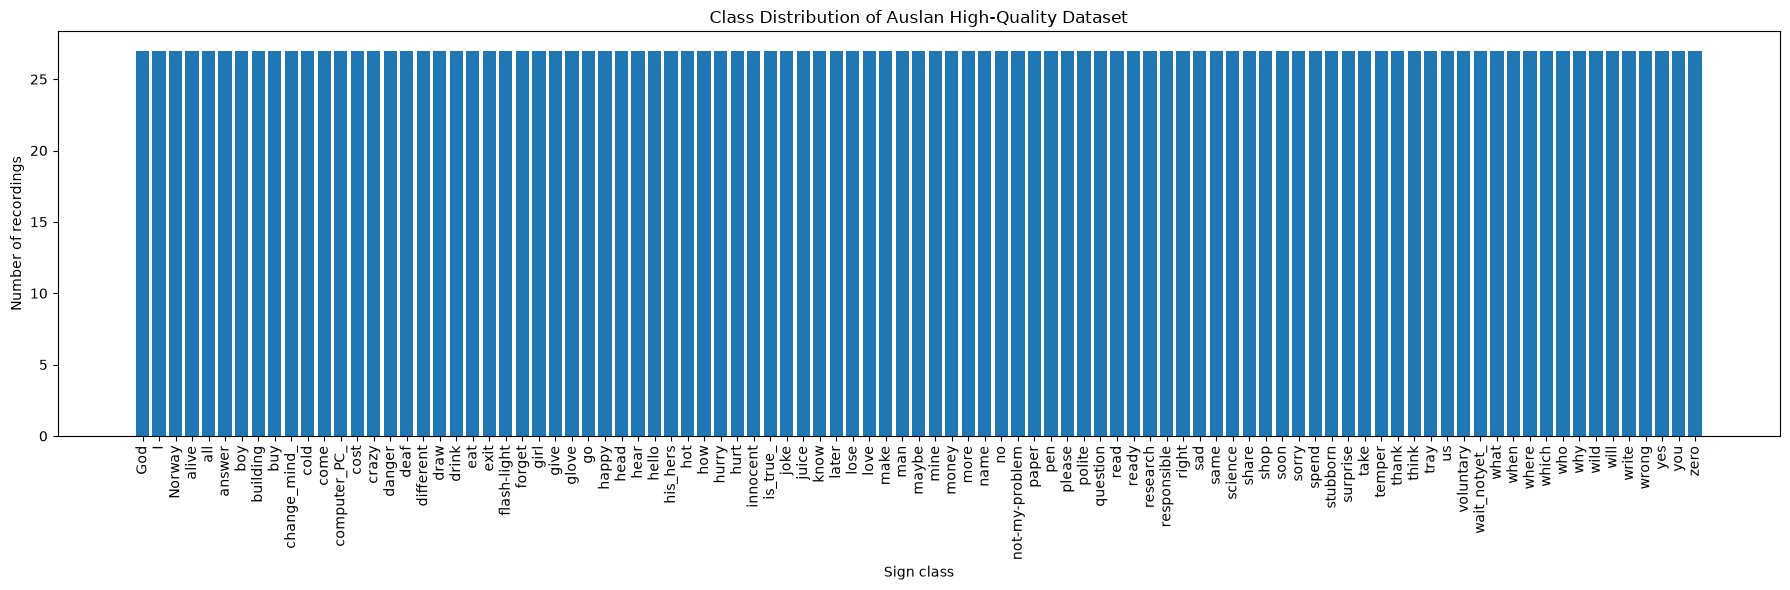

In [ ]:
import matplotlib.pyplot as plt

class_counts = metadata_clean["sign"].value_counts().sort_index()

plt.figure(figsize=(18, 6))

plt.bar(
    range(len(class_counts)),
    class_counts.values
)

plt.xlabel("Sign class")
plt.ylabel("Number of recordings")
plt.title("Class Distribution of Auslan High-Quality Dataset")

plt.xticks(
    range(len(class_counts)),
    class_counts.index,
    rotation=90
)

plt.tight_layout()
plt.show()

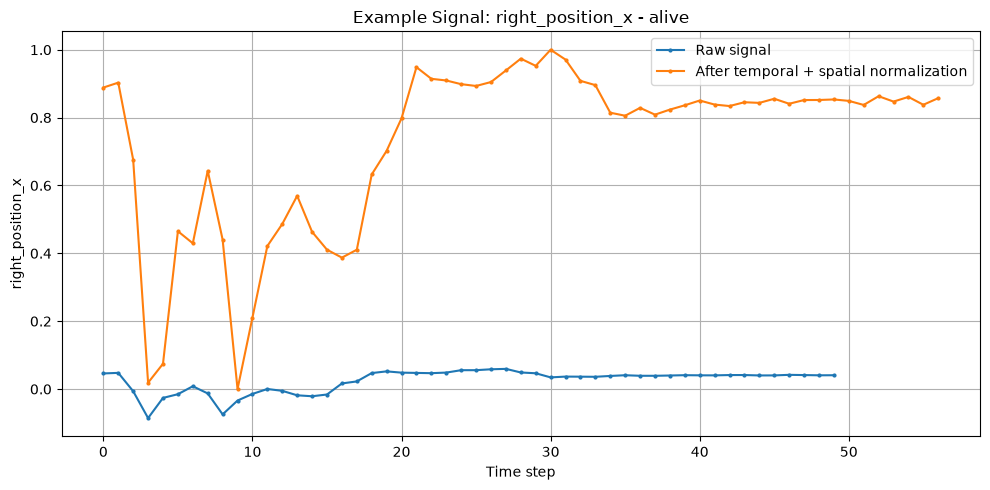

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Choose the first recording: alive-1.tsd
sample_file = metadata_clean.iloc[0]["file"]

# Load original raw recording
raw_sample = np.genfromtxt(
    sample_file,
    delimiter="\t"
)

# Right-hand X position is feature index 11
feature_index = 11
feature_name = "right_position_x"

# Find the corresponding resampled/spatial-normalized sample
processed_sample = X_spatial[0, :, feature_index]

plt.figure(figsize=(10, 5))

# Original signal
plt.plot(
    range(raw_sample.shape[0]),
    raw_sample[:, feature_index],
    marker="o",
    markersize=2,
    label="Raw signal"
)

# Processed signal
plt.plot(
    range(processed_sample.shape[0]),
    processed_sample,
    marker="o",
    markersize=2,
    label="After temporal + spatial normalization"
)

plt.xlabel("Time step")
plt.ylabel(feature_name)
plt.title(
    f"Example Signal: {feature_name} - {metadata_clean.iloc[0]['sign']}"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Data Preprocessing Summary

## Dataset
- Dataset: Australian Sign Language Signs - High Quality
- Total recordings: 2,565
- Final number of classes: 95
- Recordings per class: 27
- Features per time step: 22

## Data Quality
- Missing values (NaN): 0
- Infinite values: 0
- Exact duplicate recordings: 0
- All recordings contain 22 numerical features.

## Label Cleaning
During inspection, 3 recordings in `tctodd1` were labelled `her`,
while the corresponding sign was labelled `his_hers` in the other
recording sessions. Each session contained exactly 95 sign labels
and 3 recordings per sign. Therefore, the 3 `her` recordings were
mapped to `his_hers`.

The raw `.tsd` files were not modified. The correction was applied
only to the copied metadata used for preprocessing.

Result:
- Before correction: 96 labels
- After correction: 95 labels
- `his_hers`: 27 recordings

## Temporal Normalization
The raw recordings have variable lengths, ranging from 45 to 136
time steps, with an observed mean of approximately 57.29 time steps.

All recordings were resampled to 57 time steps using
`scipy.signal.resample`.

Result:
- Before: variable-length sequences
- After: 2,565 × 57 × 22

## Spatial Normalization
Each feature within each recording was normalized independently
using min-max scaling to the range [0, 1].

Constant features were retained because zero is a valid finger-bend
measurement and does not represent missing data.

## Train/Test Split
A session-based split was used to avoid session leakage.

Training sessions:
`tctodd1` through `tctodd6`

Testing sessions:
`tctodd7` through `tctodd9`

Result:
- Training: 1,710 recordings
- Testing: 855 recordings
- Training samples per class: 18
- Testing samples per class: 9
- Session overlap: none

## Label Encoding
The 95 sign labels were encoded as integer class IDs from 0 to 94.
The label mapping was saved separately.

## Final Representations

### LSTM
The temporal structure was preserved:
- Training shape: (1710, 57, 22)
- Testing shape: (855, 57, 22)

### SVM / Logistic Regression
The sequences were flattened:
- 57 time steps × 22 features = 1,254 features
- Training shape: (1710, 1254)
- Testing shape: (855, 1254)

## Additional Scaling
No additional `StandardScaler` transformation was applied because
spatial normalization had already placed the features in the [0, 1]
range.

## Imbalance Handling
No SMOTE, oversampling, undersampling, or class weighting was used
because all 95 classes contain the same number of recordings.

## Final Saved Files
- `auslan_lstm_processed.npz`
- `auslan_classical_processed.npz`
- `label_mapping.csv`
- `feature_mapping.csv`
- `flattened_feature_mapping.csv`
- `recording_metadata_audit.csv`
- `preprocessing_config.json`
